# Exploratory Data Analysis (EDA)

## Objective

The objective of this stage is to explore the dataset visually and statistically in order to identify patterns, relatioships and insights that may help explain customer churn.

The analysis in this notebook will be performed on train set in order to prevent from any data leakage.

The findings from this analysis will guide the data preprocessing and feature engineering steps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
file_name = '../data/processed/train.csv'
train_df = pd.read_csv(file_name)

In [3]:
train_df.shape

(5634, 20)

### Convert Senior Citizen into Categorical Feature

The `SeniorCitizen` feature is numeric binary 0/1. For better representation we convert it into categorical binary Yes/No.

In [4]:
train_df['SeniorCitizen'] = train_df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

--------

## Churn Distribution

In this section we analyze the distribution of target variable.

In [5]:
churn_count = pd.DataFrame({
    'Count': train_df['Churn'].value_counts(),
    'Percentage': train_df['Churn'].value_counts(normalize=True)
})
churn_count

,Count,Percentage
Churn,,
No,4139,0.734647
Yes,1495,0.265353


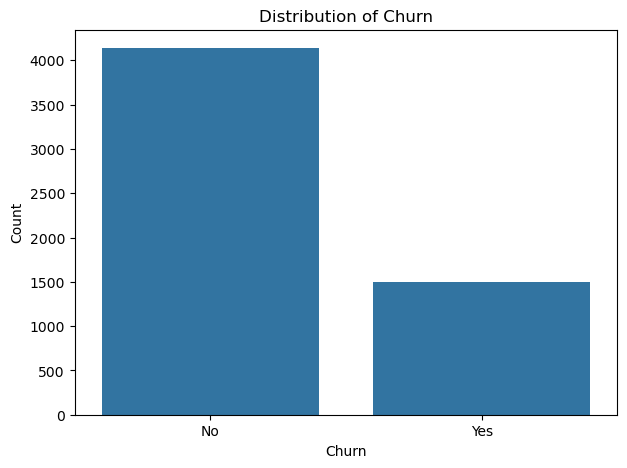

In [6]:
plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x='Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Distribution of Churn')
plt.show()

### Insight

The distribution of target variable is imbalanced so accuracy alone can not be a good metric for model evaluation.

-------

## Numerical Feature Distributions

In this section, the numerical features are explored using histograms and box plots to understand their distributions and identify potential outliers.

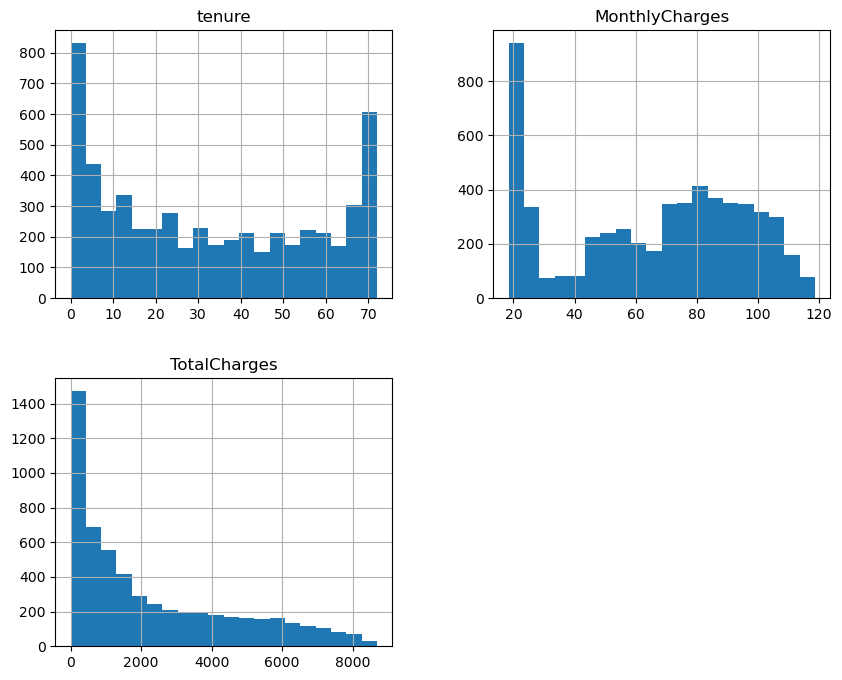

In [7]:
train_df.hist(bins = 20, figsize=(10, 8))
plt.show()

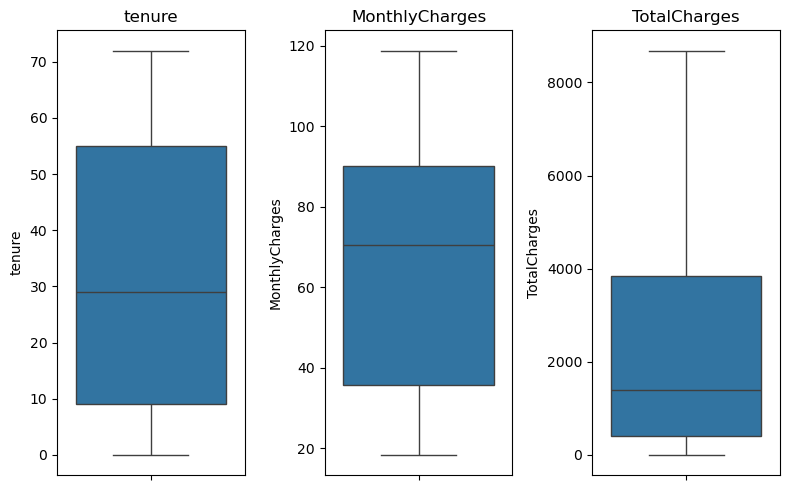

In [8]:
num_cols = train_df.select_dtypes('number').columns.tolist()
fig, axes = plt.subplots(1, 3, figsize=(8, 5))
for col, ax in zip(num_cols, axes.flat):
    sns.boxplot(
        data=train_df,
        y=col,
        ax=ax
    )
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Categorical Feature Distributions

Understanding the distribution of categorical variables helps identify dominant categories, detect potential data imbalance and gain insights into customer characteristics before analyzing their relationship with churn.

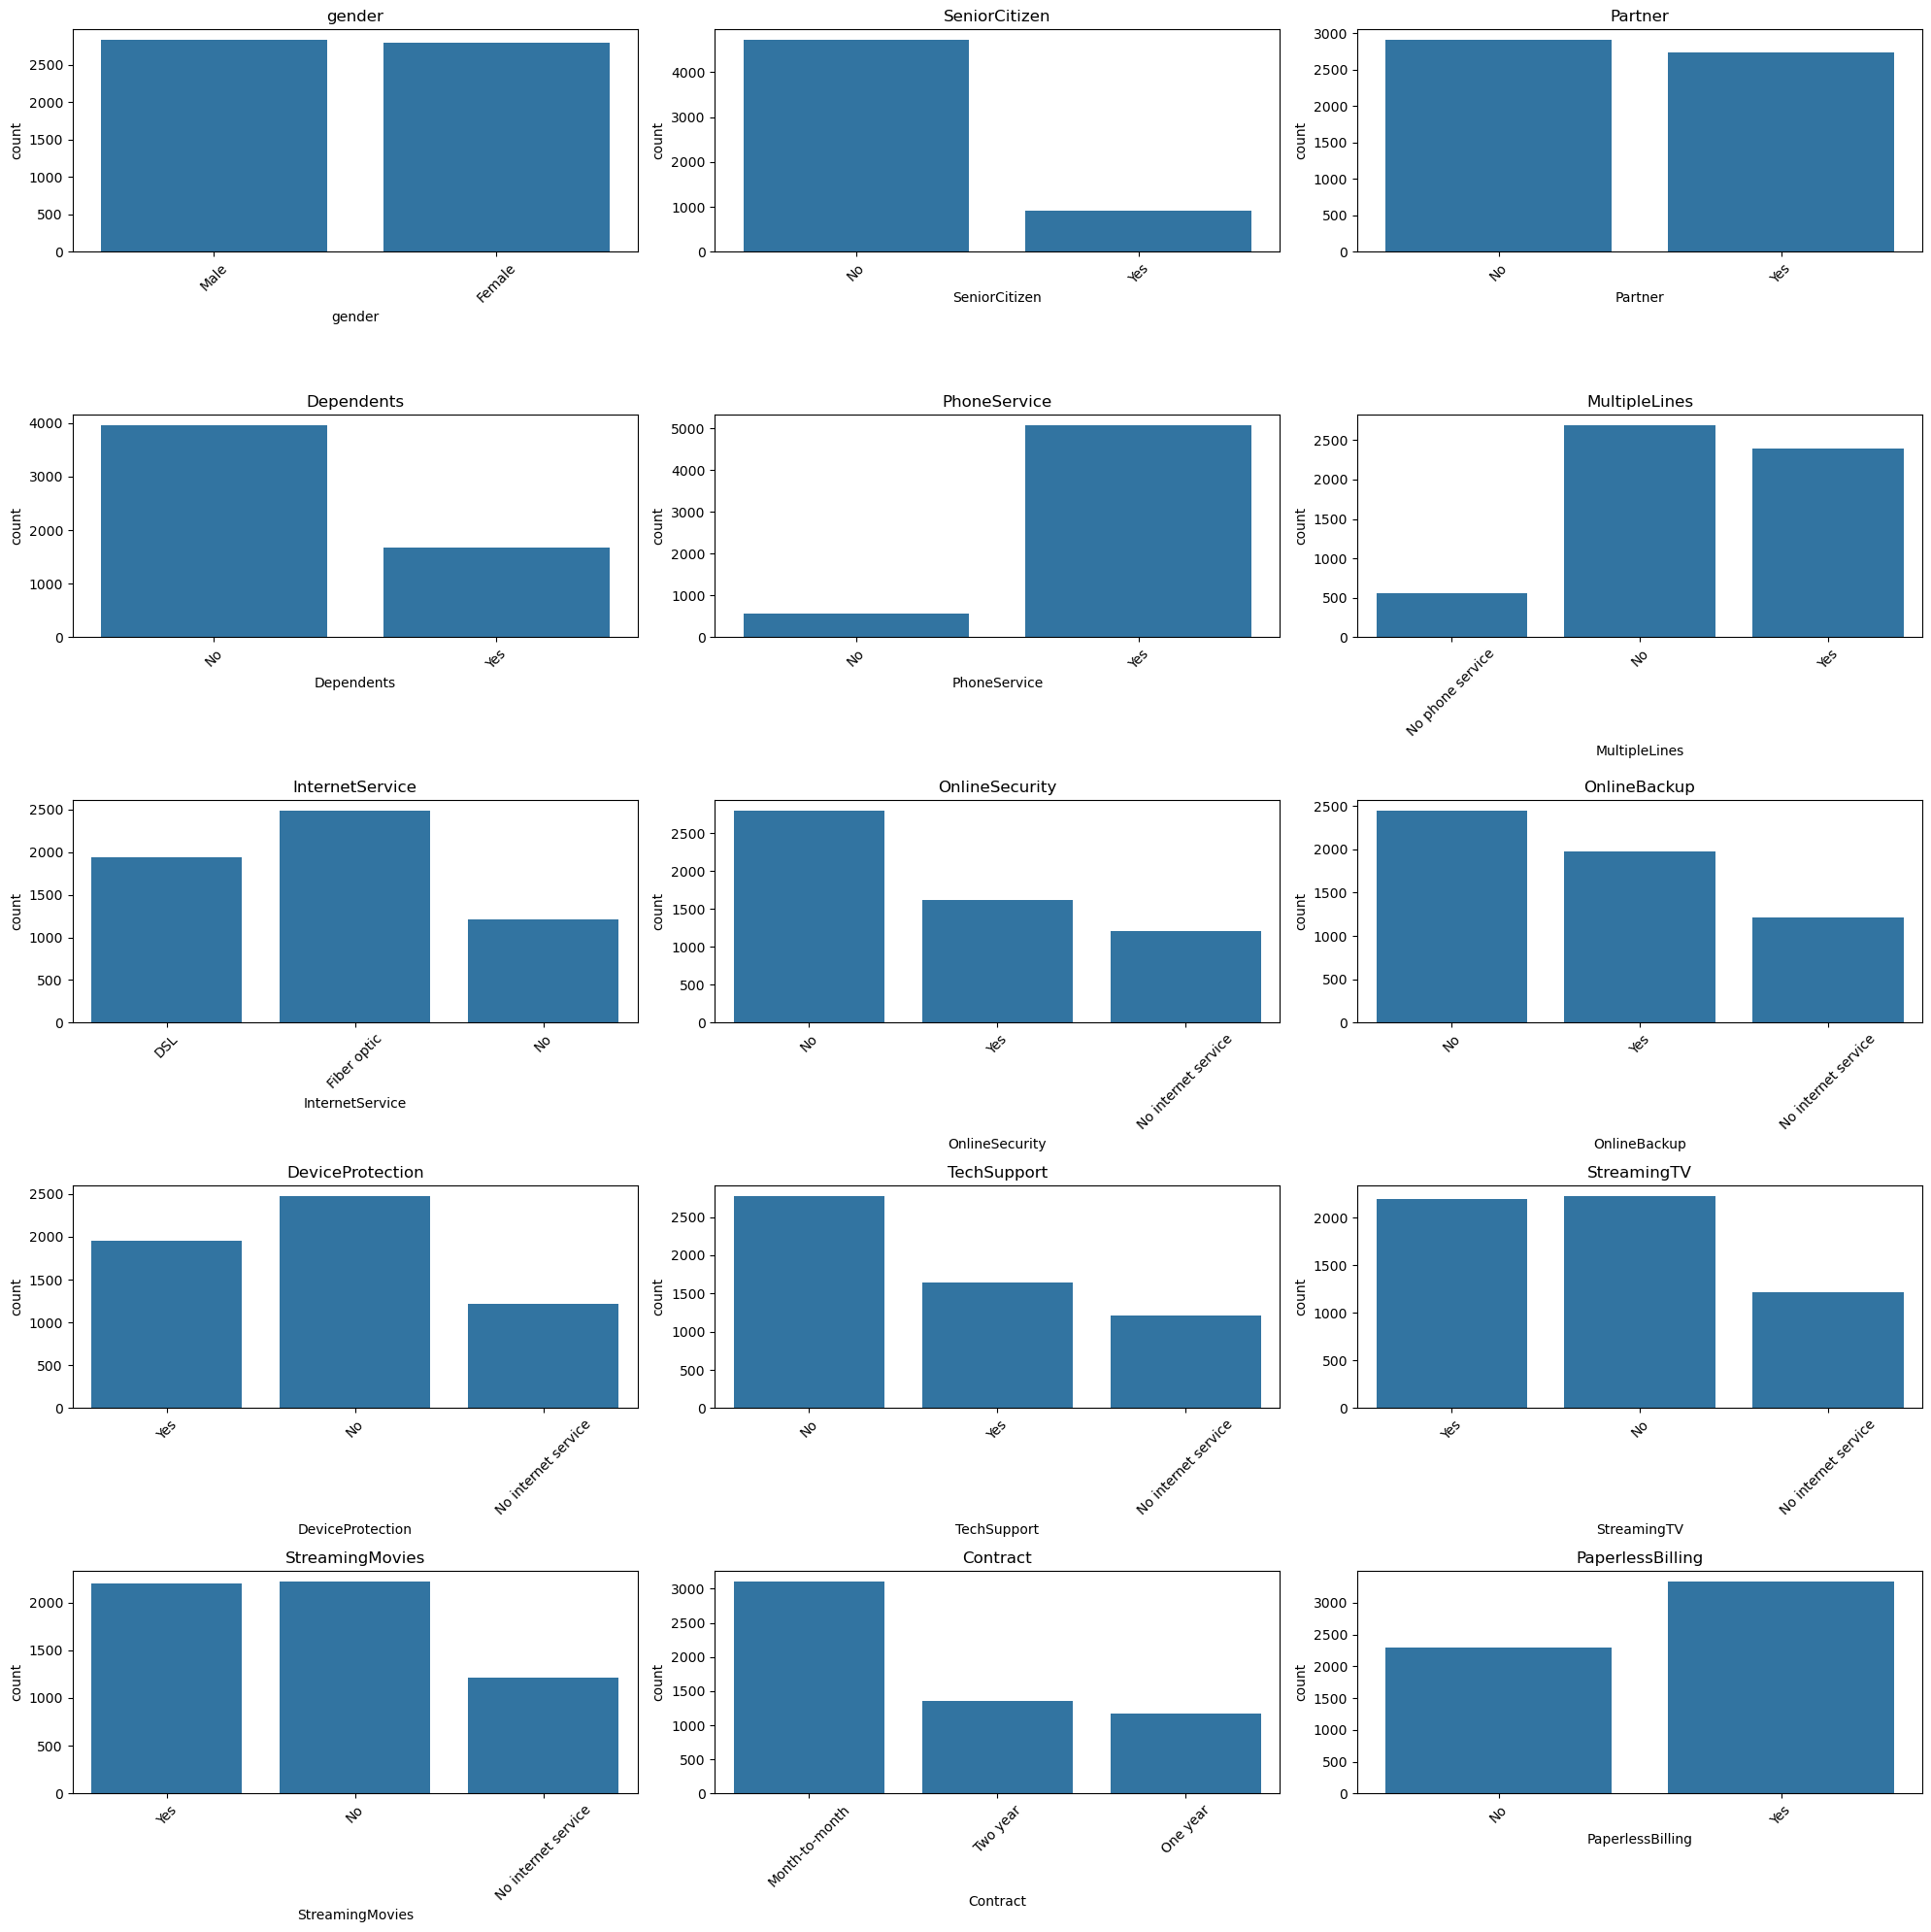

In [9]:
cat_cols = train_df.select_dtypes('object').columns.tolist()
cat_cols.remove('Churn')
fig, axes = plt.subplots(5, 3, figsize=(20, 20))
for col, ax in zip(cat_cols, axes.flat):
    sns.countplot(
        data=train_df,
        x=col,
        ax=ax
    )
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Numerical Features Analysis

In this section we analyze numerical features to find out patterns and behaviors for different groups of customers.

Questions that need to be asked:
1. Who are the customers in each peak?

In [24]:
tenure_low_peak = train_df[train_df['tenure'] <= 4]
tenure_high_peak = train_df[train_df['tenure'] >= 68]

In [25]:
tenure_low_peak.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,972,972,972,972,972.000000,972,972,972,972,972,972,972,972,972,972,972,972,972.000000,972.000000,972
unique,2,2,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,Male,No,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,Yes
freq,496,833,772,800,NaN,873,691,399,646,615,641,649,560,572,940,562,453,NaN,NaN,522
mean,NaN,NaN,NaN,NaN,1.924897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.819136,106.959516,NaN
std,NaN,NaN,NaN,NaN,1.122524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.580651,89.044077,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.750000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.875000,45.100000,NaN
50%,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.425000,75.100000,NaN
75%,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.062500,151.675000,NaN


In [26]:
tenure_high_peak.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,692,692,692,692,692.000000,692,692,692,692,692,692,692,692,692,692,692,692,692.000000,692.000000,692
unique,2,2,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,Male,No,Yes,No,NaN,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),NaN,NaN,No
freq,349,587,566,407,NaN,623,484,301,394,456,449,401,423,434,563,402,278,NaN,NaN,657
mean,NaN,NaN,NaN,NaN,70.697977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.281214,5471.419725,NaN
std,NaN,NaN,NaN,NaN,1.415174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.820965,2265.919231,NaN
min,NaN,NaN,NaN,NaN,68.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.100000,1193.550000,NaN
25%,NaN,NaN,NaN,NaN,70.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.487500,3984.912500,NaN
50%,NaN,NaN,NaN,NaN,71.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.325000,6074.200000,NaN
75%,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104.962500,7367.137500,NaN


### Tenure Analysis

After describing the lower and higher peaks of the tenure figuer, it shows that the customers with the least tenure, mostly have monthly contracts and customers with highest tenure have two-year contracts. 

Also customers in lower peak of the figure have relatively higher count of customer churns. However, the customers with highest tenure mostly do not churn.

In [27]:
monthly_charges_peak = train_df[(train_df['MonthlyCharges'] <= 25)
                                 & (train_df['MonthlyCharges'] <= 25)]

In [28]:
monthly_charges_peak.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,1111,1111,1111,1111,1111.000000,1111,1111,1111,1111,1111,1111,1111,1111,1111,1111,1111,1111,1111.000000,1111.000000,1111
unique,2,2,2,2,NaN,2,3,2,2,2,2,2,2,2,3,2,4,NaN,NaN,2
top,Male,No,No,No,NaN,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,NaN,NaN,No
freq,578,1073,601,657,NaN,1077,935,1077,1077,1077,1077,1077,1077,1077,432,781,564,NaN,NaN,1012
mean,NaN,NaN,NaN,NaN,27.941494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.670522,587.211386,NaN
std,NaN,NaN,NaN,NaN,23.626966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.721285,513.930706,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.400000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.650000,119.975000,NaN
50%,NaN,NaN,NaN,NaN,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.050000,451.550000,NaN
75%,NaN,NaN,NaN,NaN,48.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.550000,999.800000,NaN


### Monthly Charges Analysis

The Customers in the peak of Monthly Charges figure only get phone service and no other services. This results in low monthly charges and these customers mostly do not churn.

In [29]:
total_charges_peak = train_df[train_df['TotalCharges'] <= 5000]

In [30]:
total_charges_peak.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,4709,4709,4709,4709,4709.000000,4709,4709,4709,4709,4709,4709,4709,4709,4709,4709,4709,4709,4709.000000,4709.000000,4709
unique,2,2,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,Male,No,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,2381,3990,2670,3340,NaN,4150,2540,1752,2414,2233,2255,2410,2063,2057,2943,2674,1637,NaN,NaN,3344
mean,NaN,NaN,NaN,NaN,26.065194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.210682,1483.941930,NaN
std,NaN,NaN,NaN,NaN,21.487084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.064152,1410.981341,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.400000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.300000,293.300000,NaN
50%,NaN,NaN,NaN,NaN,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.500000,1023.750000,NaN
75%,NaN,NaN,NaN,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.000000,2362.100000,NaN


### Total Charges Analysis

Most out of customers are in this group. Their total charges are less than 5000 and they mostly have phone service and most about 75% of them do not churn.

## Categorical Features Relationship with Churn

In this section we explore the relationship between customer features and the target variable `Churn`.
The objective is to identify patterns that may help explain customer churn and provide useful insights for predictive modeling.

In [43]:
cat_features = train_df.select_dtypes('object').columns.to_list()
cat_features.remove('Churn')
cat_features

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [46]:
for cat in cat_features:
    print(pd.crosstab(train_df[cat], train_df['Churn'], normalize='index'))
    print()

Churn         No       Yes
gender                    
Female  0.733667  0.266333
Male    0.735616  0.264384

Churn                No       Yes
SeniorCitizen                    
No             0.763046  0.236954
Yes            0.589130  0.410870

Churn          No       Yes
Partner                    
No       0.672289  0.327711
Yes      0.801026  0.198974

Churn             No       Yes
Dependents                    
No          0.686473  0.313527
Yes         0.848124  0.151876

Churn               No       Yes
PhoneService                    
No            0.758497  0.241503
Yes           0.732020  0.267980

Churn                   No       Yes
MultipleLines                       
No                0.749721  0.250279
No phone service  0.758497  0.241503
Yes               0.712134  0.287866

Churn                  No       Yes
InternetService                    
DSL              0.813113  0.186887
Fiber optic      0.579138  0.420862
No               0.927512  0.072488

Churn           

### Insight

As we saw firstly in this notebook, among all customers 26% churn and 74% do not churn; so any featuer that breaks this dynamic can affect on churn behaviors.

Note that these findings are just possible relations and not causation.

Features that can affect customer churn:
- **Senior Citezenship**: 41% of senior citizens churn opposed to the 23% non-senior citizens that churn.

- Partner and Dependents: customers who have a partner or dependents are less likely to churn.

- Internet Service: customers with fiber optic service are more likely to churn.
- Among customers who get internet service, those who do not have other additional services such as online security, online backup, device protection and tech support, are more likely to churn.
- **Contract**: Month-to-month contracts have the highest rate of customer churn where long-term contracts have few churning customers.
- Paperless Billing: customers with paperless billing are more likely to churn. Its interesting since paperless billing could make it easier for paying the bill.
- Payment Method: customers with electronic check method are more likely to churn.

In [48]:
pd.crosstab(train_df['PaperlessBilling'], train_df['Contract'], normalize='index')

Contract,Month-to-month,One year,Two year
PaperlessBilling,,,
No,0.451151,0.237082,0.311767
Yes,0.619334,0.188232,0.192435


In [49]:
pd.crosstab(train_df['PaymentMethod'], train_df['Contract'], normalize='index')

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),0.382637,0.249196,0.368167
Credit card (automatic),0.350371,0.262984,0.386645
Electronic check,0.784770,0.147012,0.068218
Mailed check,0.557543,0.206843,0.235614


In [50]:
pd.crosstab(train_df['PaperlessBilling'], train_df['SeniorCitizen'], normalize='index')

SeniorCitizen,No,Yes
PaperlessBilling,,
No,0.906644,0.093356
Yes,0.788352,0.211648


In [51]:
pd.crosstab(train_df['PaymentMethod'], train_df['SeniorCitizen'], normalize='index')

SeniorCitizen,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.848071,0.151929
Credit card (automatic),0.858203,0.141797
Electronic check,0.745637,0.254363
Mailed check,0.939347,0.060653


## EDA Summary

Based on the exploratory data analysis, several important patterns were identified:

- The target variable `Churn` is imbalanced with fewer churned customers compared to retained customers.

- Customers with shorter tenure appear to have a higher tendency to churn, while long-term customers are more likely to stay.

- Contract type shows a strong relationship with churn. Customers with monthly contracts have higher churn compared to customers with long-term contracts.
- Customers who churned are more frequently associated with the absence of additional services such as OnlineSecurity and TechSupport.
- Fiber optic internet service appears frequently among churned customers and requires further investigations.
- Electronic check is the most common payment method among churned customers.
- Customers who churned generally have lower total charges, although some hugh-value customers also churned.

